# Notebook 01 – Data Preprocessing (CIC-DDoS2019-IDS2017)

**Pipeline stages covered:**
0. Load `ready_dataset.csv` from `data/CIC-DDoS2019-IDS2017/`
1. Exploratory visualization (class distribution, null values)
2. Remove duplicates, NaN / Inf values
3. Optionally sample to keep dataset manageable
4. Visualize cleaned data
5. Persist cleaned dataset for Notebook 02

> **Data leakage note:** Scaling and encoding are intentionally deferred to
> Notebook 02, *after* the train/test split.

## 0 · Load Raw Dataset

The CIC-DDoS2019-IDS2017 dataset is provided as a single pre-combined CSV.
We strip leading/trailing whitespace from all column names immediately after loading.

In [ ]:
# ── Section 0: Configuration ─────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RAW_CSV      = '../../data/CIC-DDoS2019-IDS2017/ready_dataset.csv'
OUTPUT_DIR   = '../../data/processed-ids2017'
LABEL_COL    = 'Label'
MAX_ROWS     = 150_000   # cap per class; set to None to keep all
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Raw CSV    : {os.path.abspath(RAW_CSV)}')
print(f'Output dir : {os.path.abspath(OUTPUT_DIR)}')
print(f'Max rows   : {MAX_ROWS}')

Raw CSV    : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\data\CIC-DDoS2019-IDS2017\ready_dataset.csv
Output dir : e:\Documents\Programming\Python\project\AI\Transformer DDoS Detector\data\processed-ids2017
Max rows   : 150000


In [2]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
print('Loading ready_dataset.csv … (this may take a minute)')
df_raw = pd.read_csv(RAW_CSV, low_memory=False)

# Strip whitespace from column names (IDS2017 has leading spaces)
df_raw.columns = df_raw.columns.str.strip()

print(f'Loaded : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print(f'Columns: {list(df_raw.columns)}')

Loading ready_dataset.csv … (this may take a minute)
Loaded : 9,209,309 rows × 78 cols
Columns: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag C

## 1 · Exploratory Visualization

In [3]:
# Class distribution before cleaning
class_counts = df_raw[LABEL_COL].value_counts()
print('=== Class distribution (raw) ===')
print(class_counts.to_string())
print(f'\nTotal classes: {class_counts.shape[0]}')
print(f'Total rows   : {df_raw.shape[0]:,}')

=== Class distribution (raw) ===
Label
BENIGN     2384051
TFTP       1951336
MSSQL       998191
NetBIOS     747772
UDP         688393
Syn         594129
SNMP        514957
DNS         490813
LDAP        410301
SSDP        256832
NTP         119528
UDPLag       34891
Portmap      17676
WebDDoS        439

Total classes: 14
Total rows   : 9,209,309


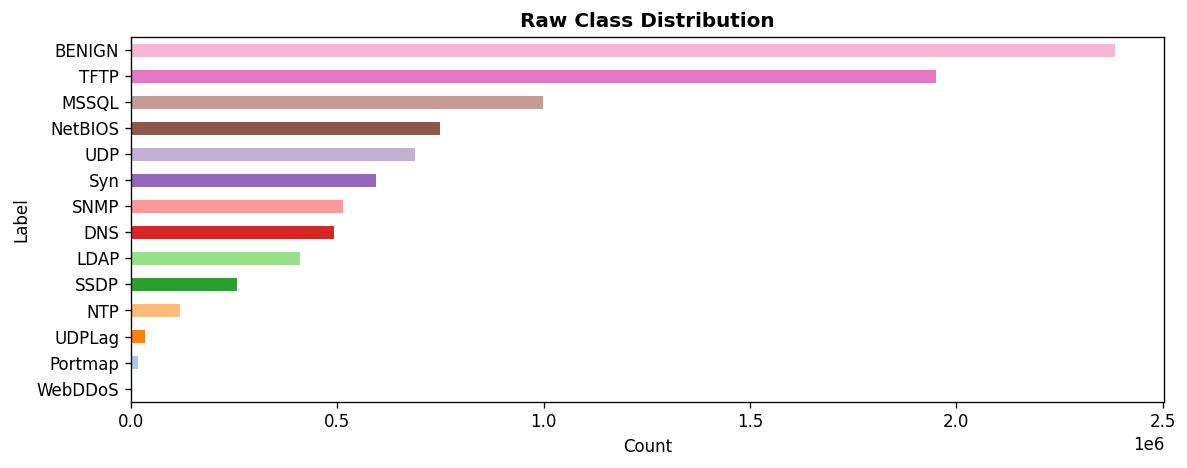

In [4]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
class_counts.sort_values().plot(kind='barh', ax=ax, color=plt.cm.tab20.colors[:len(class_counts)])
ax.set_title('Raw Class Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# NaN / Inf overview
nan_counts = df_raw.isnull().sum()
inf_counts = df_raw.isin([float('inf'), float('-inf')]).sum()
bad = pd.DataFrame({'NaN': nan_counts, 'Inf': inf_counts})
bad = bad[bad.sum(axis=1) > 0]
if bad.empty:
    print('No NaN or Inf values found in raw dataset.')
else:
    print('Columns with NaN / Inf values:')
    print(bad)

No NaN or Inf values found in raw dataset.


## 2 · Clean – Remove Duplicates, NaN / Inf

In [6]:
df = df_raw.copy()
n0 = len(df)

# Replace Inf with NaN then drop
df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
df.dropna(inplace=True)
n1 = len(df)
print(f'Removed NaN/Inf: {n0 - n1:,} rows removed  ({n1:,} remaining)')

# Remove duplicate rows
df.drop_duplicates(inplace=True)
n2 = len(df)
print(f'Removed duplicates: {n1 - n2:,} rows removed  ({n2:,} remaining)')

Removed NaN/Inf: 0 rows removed  (9,209,309 remaining)
Removed duplicates: 5,798,634 rows removed  (3,410,675 remaining)


## 3 · Optional Sampling (cap per class)

In [7]:
if MAX_ROWS is not None:
    groups = []
    for label, grp in df.groupby(LABEL_COL):
        if len(grp) > MAX_ROWS:
            grp = grp.sample(MAX_ROWS, random_state=RANDOM_STATE)
            print(f'  Sampled {label}: {MAX_ROWS:,} rows')
        else:
            print(f'  Kept   {label}: {len(grp):,} rows (under cap)')
        groups.append(grp)
    df = pd.concat(groups).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'\nDataset after sampling: {df.shape[0]:,} rows × {df.shape[1]} cols')
print('Class distribution after sampling:')
print(df[LABEL_COL].value_counts().to_string())

  Sampled BENIGN: 150,000 rows
  Kept   DNS: 24,515 rows (under cap)
  Kept   LDAP: 9,978 rows (under cap)
  Kept   MSSQL: 95,747 rows (under cap)
  Kept   NTP: 112,997 rows (under cap)
  Kept   NetBIOS: 5,701 rows (under cap)
  Kept   Portmap: 427 rows (under cap)
  Kept   SNMP: 24,411 rows (under cap)
  Kept   SSDP: 115,618 rows (under cap)
  Kept   Syn: 81,167 rows (under cap)
  Sampled TFTP: 150,000 rows
  Sampled UDP: 150,000 rows
  Kept   UDPLag: 10,297 rows (under cap)
  Kept   WebDDoS: 414 rows (under cap)

Dataset after sampling: 931,272 rows × 78 cols
Class distribution after sampling:
Label
TFTP       150000
UDP        150000
BENIGN     150000
SSDP       115618
NTP        112997
MSSQL       95747
Syn         81167
DNS         24515
SNMP        24411
UDPLag      10297
LDAP         9978
NetBIOS      5701
Portmap       427
WebDDoS       414


## 4 · Visualize Cleaned Data

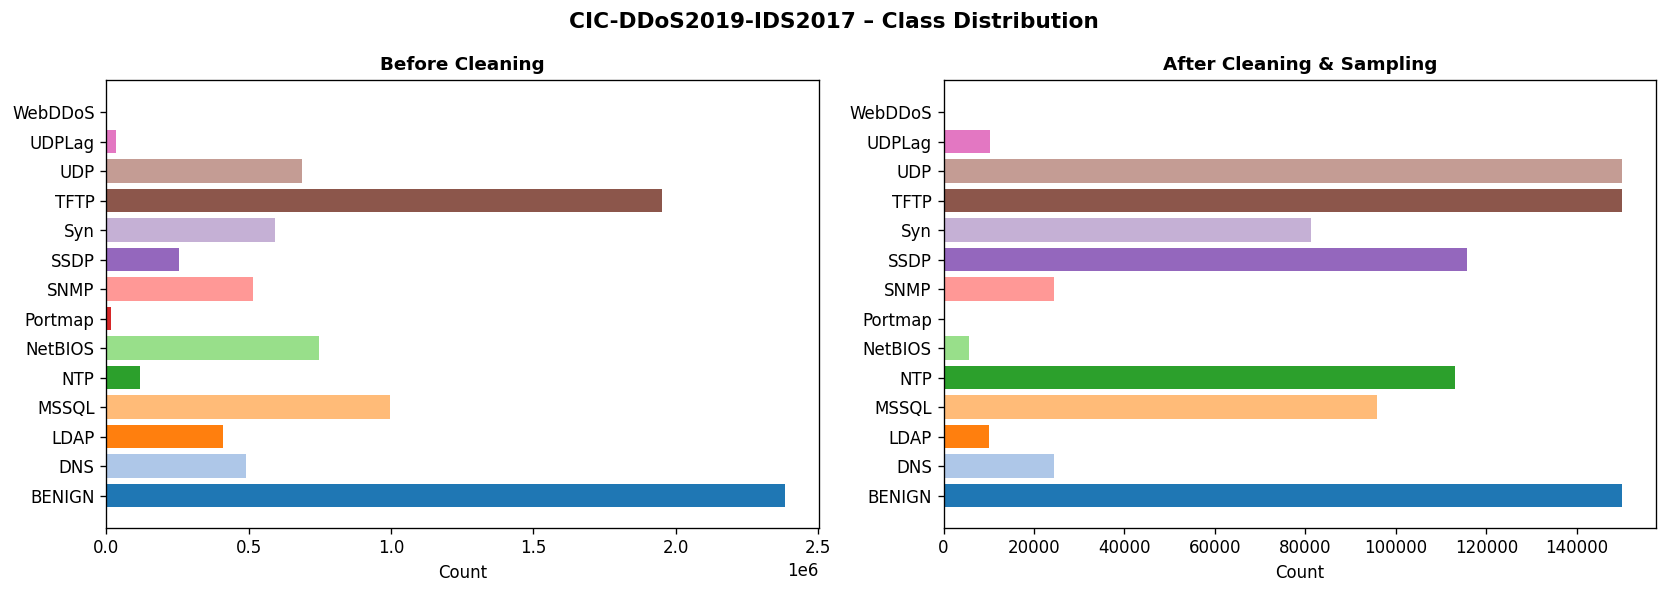

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Before
cc_before = df_raw[LABEL_COL].value_counts().sort_index()
ax1.barh(cc_before.index, cc_before.values, color=plt.cm.tab20.colors[:len(cc_before)])
ax1.set_title('Before Cleaning', fontsize=11, fontweight='bold')
ax1.set_xlabel('Count')

# After
cc_after = df[LABEL_COL].value_counts().sort_index()
ax2.barh(cc_after.index, cc_after.values, color=plt.cm.tab20.colors[:len(cc_after)])
ax2.set_title('After Cleaning & Sampling', fontsize=11, fontweight='bold')
ax2.set_xlabel('Count')

plt.suptitle('CIC-DDoS2019-IDS2017 – Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig_01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Feature type overview
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric  = [c for c in df.columns if c not in numeric_cols]

print(f'Numeric columns : {len(numeric_cols)}')
print(f'Non-numeric cols: {len(non_numeric)}  → {non_numeric}')

Numeric columns : 77
Non-numeric cols: 1  → ['Label']


## 5 · Basic Statistics

In [10]:
df[numeric_cols].describe().T[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(4)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,931272.0,7.333912e+06,2.105431e+07,-1.0,293.0,107684.0,2999516.0,119999998.0
Total Fwd Packets,931272.0,1.713670e+01,6.448163e+02,1.0,2.0,4.0,6.0,217797.0
Total Backward Packets,931272.0,2.396500e+00,4.686612e+02,0.0,0.0,0.0,0.0,289585.0
Total Length of Fwd Packets,931272.0,5.118826e+03,1.931863e+04,0.0,810.0,1446.0,2414.0,12900000.0
Total Length of Bwd Packets,931272.0,3.084768e+03,1.035873e+06,0.0,0.0,0.0,0.0,639650620.0
...,...,...,...,...,...,...,...,...
Active Min,931272.0,1.136126e+04,2.702933e+05,0.0,0.0,0.0,0.0,106000000.0
Idle Mean,931272.0,1.949852e+06,7.417164e+06,0.0,0.0,0.0,0.0,120000000.0
Idle Std,931272.0,4.161074e+05,2.050583e+06,0.0,0.0,0.0,0.0,71600000.0
Idle Max,931272.0,2.413245e+06,8.615274e+06,0.0,0.0,0.0,0.0,120000000.0


## 6 · Persist Cleaned Dataset

In [11]:
out_path = f'{OUTPUT_DIR}/cleaned_dataset.parquet'
df.to_parquet(out_path, index=False)
print(f'✓ Cleaned dataset saved → {out_path}')
print(f'  Shape : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Classes: {df[LABEL_COL].nunique()}  → {sorted(df[LABEL_COL].unique().tolist())}')

✓ Cleaned dataset saved → ../../data/processed-ids2017/cleaned_dataset.parquet
  Shape : 931,272 rows × 78 cols
  Classes: 14  → ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS', 'Portmap', 'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag', 'WebDDoS']
